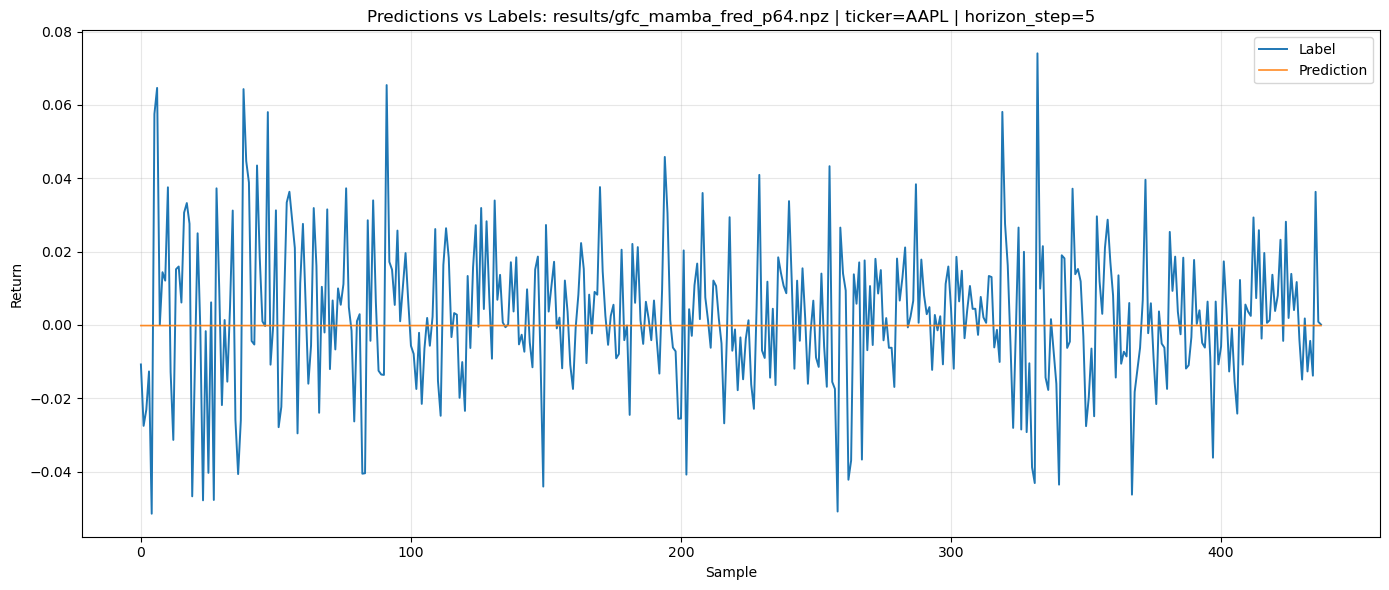

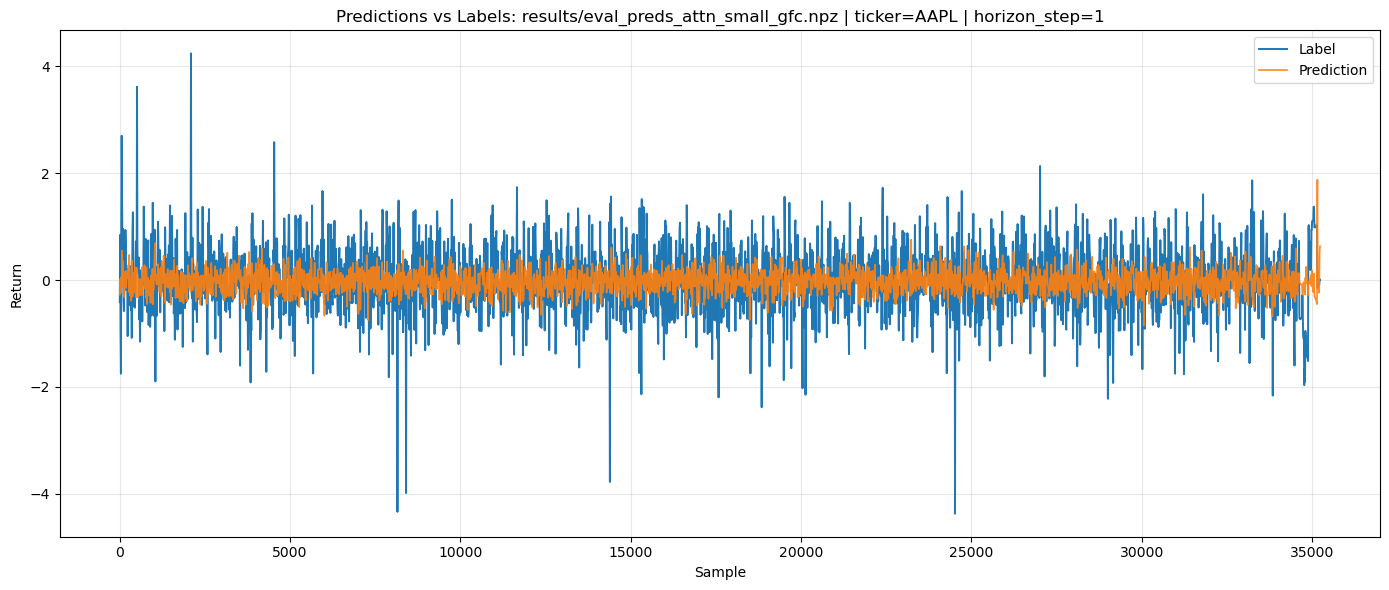

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _pick_first_key(data, candidates):
    for k in candidates:
        if k in data:
            return k
    return None


def plot_npz_preds_vs_labels(
    npz_path,
    ticker=None,
    horizon_step=1,
    aggregate_by_date=True,
    start_date=None,
    end_date=None,
    max_points=3000,
):
    data = np.load(npz_path, allow_pickle=True)

    pred_key = _pick_first_key(data, ["predictions", "preds", "y_pred", "forecast", "outputs"])
    label_key = _pick_first_key(data, ["labels", "targets", "y_true", "ground_truth"])
    date_key = _pick_first_key(data, ["dates", "date", "timestamps", "time"])
    ticker_key = _pick_first_key(data, ["tickers", "ticker", "symbols", "symbol"])

    if pred_key is None or label_key is None:
        raise ValueError(
            f"Could not find prediction/label keys in {npz_path}. Found keys: {list(data.files)}"
        )

    preds = np.asarray(data[pred_key])
    labels = np.asarray(data[label_key])

    # Handle common [N, H] horizon format.
    if preds.ndim == 2 and labels.ndim == 2:
        h = horizon_step - 1
        if h < 0 or h >= preds.shape[1] or h >= labels.shape[1]:
            raise ValueError(f"horizon_step={horizon_step} out of range for shape {preds.shape}/{labels.shape}")
        preds_1d = preds[:, h]
        labels_1d = labels[:, h]
        n, horizon = preds.shape[0], preds.shape[1]
    else:
        # Fallback: squeeze and flatten to 1D.
        preds_1d = np.asarray(preds).squeeze().reshape(-1)
        labels_1d = np.asarray(labels).squeeze().reshape(-1)
        n, horizon = preds_1d.shape[0], 1

    m = min(preds_1d.size, labels_1d.size)
    preds_1d = preds_1d[:m]
    labels_1d = labels_1d[:m]

    df = pd.DataFrame({"pred": preds_1d, "true": labels_1d})

    # Optional ticker handling for shapes [N] or [N*H].
    if ticker_key is not None:
        tk = np.asarray(data[ticker_key]).reshape(-1)
        if tk.size == m:
            df["ticker"] = tk
        elif horizon > 1 and tk.size == n:
            # If we selected one horizon, length should be N.
            df["ticker"] = tk[:m]

        if ticker is not None and "ticker" in df.columns:
            df = df[df["ticker"].astype(str) == str(ticker)]

    # Optional date handling for shapes [N], [N*H], [N,H].
    if date_key is not None:
        raw_dates = np.asarray(data[date_key])
        flat_dates = np.asarray(pd.to_datetime(raw_dates.reshape(-1), errors="coerce"))

        if flat_dates.size == m:
            df["date"] = flat_dates
        elif horizon > 1 and flat_dates.size == n:
            df["date"] = flat_dates[: len(df)]
        elif raw_dates.ndim == 2 and raw_dates.shape[0] == n and raw_dates.shape[1] >= horizon_step:
            dcol = np.asarray(pd.to_datetime(raw_dates[:, horizon_step - 1], errors="coerce"))
            df["date"] = dcol[: len(df)]

    if "date" in df.columns:
        if start_date is not None:
            df = df[df["date"] >= pd.to_datetime(start_date)]
        if end_date is not None:
            df = df[df["date"] <= pd.to_datetime(end_date)]

        if aggregate_by_date:
            grp_cols = ["date"]
            if ticker is None and "ticker" in df.columns:
                grp_cols.append("ticker")
            df = df.groupby(grp_cols, as_index=False)[["pred", "true"]].mean()

        df = df.sort_values("date")
        x = df["date"]
        xlabel = "Date"
    else:
        df = df.reset_index(drop=True)
        x = df.index
        xlabel = "Sample"

    if len(df) == 0:
        raise ValueError("No rows left to plot after filtering.")

    if len(df) > max_points:
        step = max(1, len(df) // max_points)
        df = df.iloc[::step].copy()
        if "date" in df.columns:
            x = df["date"]
        else:
            x = df.index

    plt.figure(figsize=(14, 6))
    plt.plot(x, df["true"], label="Label", linewidth=1.4)
    plt.plot(x, df["pred"], label="Prediction", linewidth=1.2, alpha=0.9)

    title = f"Predictions vs Labels: {npz_path}"
    if ticker is not None:
        title += f" | ticker={ticker}"
    if horizon > 1:
        title += f" | horizon_step={horizon_step}"

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Return")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example 1: gfc mamba (usually horizon-format)
plot_npz_preds_vs_labels(
    "results/gfc_mamba_fred_p64.npz",
    ticker="AAPL",
    horizon_step=5,
    aggregate_by_date=True,
)

# Example 2: attn small covid (different structure supported)
plot_npz_preds_vs_labels(
    "results/eval_preds_attn_small_gfc.npz",
    ticker="AAPL",
    horizon_step=1,
    aggregate_by_date=True,
)


In [22]:
import numpy as np
import pandas as pd


def npz_date_bounds(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    for k in ["dates", "date", "timestamps", "time"]:
        if k in data:
            d = pd.to_datetime(np.asarray(data[k]).reshape(-1), errors="coerce")
            d = d[~pd.isna(d)]
            if len(d):
                return d.min(), d.max()
    raise ValueError(f"No parseable dates found in {npz_path}. Keys: {list(data.files)}")


def common_date_window(npz_paths):
    bounds = [npz_date_bounds(p) for p in npz_paths]
    start = max(b[0] for b in bounds)  # intersection start
    end = min(b[1] for b in bounds)    # intersection end
    if start > end:
        raise ValueError(f"No overlapping date range across files: {bounds}")
    return start, end


paths = [
    "results/gfc_mamba_fred_p64.npz",
    "results/eval_preds_attn_small_covid.npz",
]

shared_start, shared_end = common_date_window(paths)
print("Shared x-axis window:", shared_start.date(), "->", shared_end.date())

# Plot 1 with shared x-range
plot_npz_preds_vs_labels(
    "results/gfc_mamba_fred_p64.npz",
    ticker="AAPL",
    horizon_step=5,
    aggregate_by_date=True,
    start_date=shared_start,
    end_date=shared_end,
)

# Plot 2 with exactly same x-range
plot_npz_preds_vs_labels(
    "results/eval_preds_attn_small_covid.npz",
    ticker="AAPL",
    horizon_step=1,
    aggregate_by_date=True,
    start_date=shared_start,
    end_date=shared_end,
)


ValueError: No parseable dates found in results/eval_preds_attn_small_covid.npz. Keys: ['predictions', 'labels']

In [3]:
!pip install pandas_datareader

Looking in indexes: http://nexus.charisma:5080/repository/pypi-proxy/simple


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from pandas_datareader import data as pdr

START = "1995-01-01"
END   = "2025-12-01"
MARKET = "SPY"  # or "^GSPC"

FRED_SERIES = {
    "DFF": "fed_funds",
    "DGS10": "rate_10y",
    "DGS2": "rate_2y",
    "T10Y2Y": "yc_slope_10y2y",
    # "CPIAUCSL": "cpi",
    # "UNRATE": "unemp",
    # "INDPRO": "indpro",
    "VIXCLS": "vix",
    "DBAA": "dbaa",
    "DAAA": "daaa",
}

# Evaluation eras (held out from training)
SPLITS = {
    "gfc_2008_2010": ("2008-01-01", "2010-12-31"),
    "covid_2020_2021": ("2020-01-01", "2021-12-31"),
    "inflation_2022_2023": ("2022-01-01", "2023-12-31"),
}

OUT_ROOT = "dataset_finance_no_activity"


def ensure_dirs():
    os.makedirs(os.path.join(OUT_ROOT, "metadata"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "finetune"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "eval"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "eval_jsonl"), exist_ok=True)

def get_sp500_tickers() -> list[str]:
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/91.0.4472.124 Safari/537.36"
        )
    }
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()
    return [t.replace(".", "-") for t in tickers]


def download_close(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    px = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    price_field = "Close"  # or "Adj Close"

    if isinstance(px.columns, pd.MultiIndex):
        close = pd.concat(
            {t: px[t][price_field] for t in tickers if t in px.columns.get_level_values(0)},
            axis=1,
        )
    else:
        close = px[price_field].to_frame(tickers[0])

    return close.sort_index()


def log_returns(close_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(close_df).diff()


def download_fred(series_map: dict, start: str, end: str) -> pd.DataFrame:
    macro = pdr.DataReader(list(series_map.keys()), "fred", start, end)
    return macro.rename(columns=series_map).sort_index()


def save_metadata(tickers: list[str]):
    pd.Series(tickers, name="ticker").to_csv(os.path.join(OUT_ROOT, "metadata", "tickers.csv"), index=False)
    pd.DataFrame({"fred_code": list(FRED_SERIES.keys()), "name": list(FRED_SERIES.values())}).to_csv(
        os.path.join(OUT_ROOT, "metadata", "fred_series.csv"), index=False
    )
    with open(os.path.join(OUT_ROOT, "metadata", "build_config.json"), "w") as f:
        json.dump(
            {"start": START, "end": END, "market": MARKET, "fred_series": FRED_SERIES, "splits": SPLITS},
            f,
            indent=2,
        )


def _build_exclusion_mask(index: pd.DatetimeIndex, splits: dict) -> pd.Series:
    """True = keep for training, False = exclude (eval eras)."""
    keep = pd.Series(True, index=index)
    for _, (a, b) in splits.items():
        keep.loc[a:b] = False
    return keep


def _contiguous_segments_from_masked_series(
    s: pd.Series,
    keep_mask: pd.Series,
    min_len: int,
    max_gap_days: int = 7,
):
    """
    Returns list of contiguous sequences from s where keep_mask is True.
    Contiguity is defined by date gaps <= max_gap_days (trading calendar gaps OK).
    """
    # Keep only dates allowed for training
    s2 = s[keep_mask].dropna()
    if len(s2) == 0:
        return []

    # Identify breaks where the date gap is too large
    dt = s2.index.to_series().diff().dt.days.fillna(1)
    # A large gap implies we're jumping across excluded eras or missing chunks
    breaks = (dt > max_gap_days).cumsum()

    segments = []
    for _, seg in s2.groupby(breaks):
        if len(seg) >= min_len:
            segments.append(seg.astype(float).to_list())
    return segments

def transform_macro(macro: pd.DataFrame) -> pd.DataFrame:
    macro = macro.copy()

    # growth-style transforms for slow macro variables
    if "cpi" in macro.columns:
        macro["cpi"] = macro["cpi"].pct_change(12)

    if "indpro" in macro.columns:
        macro["indpro"] = macro["indpro"].pct_change(12)

    # credit spread
    if "dbaa" in macro.columns and "daaa" in macro.columns:
        macro["baa_aaa_spread"] = macro["dbaa"] - macro["daaa"]

    # keep vix in levels
    # keep rates / slope / unemployment in levels

    # optional: drop raw corporate bond yields after building spread
    drop_cols = [c for c in ["dbaa", "daaa"] if c in macro.columns]
    macro = macro.drop(columns=drop_cols, errors="ignore")

    return macro


def write_train_jsonl_contiguous_covariates(
    firm_rets: pd.DataFrame,
    market_ret: pd.Series,
    macro: pd.DataFrame,
    splits: dict,
    out_path: str,
    min_len: int = 512,
    max_gap_days: int = 7,
):
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)

    keep_mask = _build_exclusion_mask(firm_rets.index, splits)

    n_seq = 0
    n_tickers = 0

    with open(out_path, "w", encoding="utf-8") as f:
        for t in firm_rets.columns:
            y = firm_rets[t].copy()

            df = pd.DataFrame({
                "sequence": y,
                "market_ret_1d": market_ret,
            }, index=firm_rets.index)

            for c in macro.columns:
                df[c] = macro[c]

            df = df[keep_mask].dropna()

            if len(df) == 0:
                continue

            dt = df.index.to_series().diff().dt.days.fillna(1)
            breaks = (dt > max_gap_days).cumsum()

            seg_id = 0
            wrote_any = False

            for _, seg in df.groupby(breaks):
                if len(seg) < min_len:
                    continue

                obj = {
                    "ticker": t,
                    "segment_id": seg_id,
                    "sequence": seg["sequence"].astype(float).tolist(),
                    "main_features": seg[["sequence", "market_ret_1d"]].astype(float).values.tolist(),
                    "macro_features": seg[list(macro.columns)].astype(float).values.tolist(),
                }
                f.write(json.dumps(obj) + "\n")
                seg_id += 1
                n_seq += 1
                wrote_any = True

            if wrote_any:
                n_tickers += 1

    total_dates = len(firm_rets.index)
    train_dates = int(keep_mask.sum())
    eval_dates = total_dates - train_dates

    print(f"[split] total dates={total_dates} | train dates={train_dates} | eval-excluded dates={eval_dates}")
    print(f"[train.jsonl] wrote {n_seq} sequences from {n_tickers} tickers to {out_path}")


def write_eval_csvs(panel_wide: pd.DataFrame, splits: dict):
    eval_dir = os.path.join(OUT_ROOT, "eval")
    os.makedirs(eval_dir, exist_ok=True)

    for name, (a, b) in splits.items():
        df = panel_wide.loc[a:b].copy()
        df.reset_index().rename(columns={"index": "date"}).to_csv(os.path.join(eval_dir, f"{name}.csv"), index=False)

def write_eval_jsonl_for_split(
    split_name: str,
    split_range: tuple[str, str],
    firm_rets: pd.DataFrame,
    market_ret: pd.Series,
    macro: pd.DataFrame,
    out_path: str,
    min_len: int = 32,
):
    a, b = split_range

    n_seq = 0
    n_tickers = 0

    with open(out_path, "w", encoding="utf-8") as f:
        for t in firm_rets.columns:
            df = pd.DataFrame(index=firm_rets.index)
            df["sequence"] = firm_rets[t]
            df["market_ret_1d"] = market_ret
            for c in macro.columns:
                df[c] = macro[c]

            df = df.loc[a:b].dropna()

            if len(df) < min_len:
                continue

            obj = {
                "ticker": t,
                "segment_id": 0,
                "dates": [d.strftime("%Y-%m-%d") for d in df.index],
                "sequence": df["sequence"].astype(float).tolist(),
                "main_features": df[["sequence", "market_ret_1d"]].astype(float).values.tolist(),
                "macro_features": df[list(macro.columns)].astype(float).values.tolist(),
            }
            f.write(json.dumps(obj) + "\n")
            n_seq += 1
            n_tickers += 1

    print(f"[{split_name}] wrote {n_seq} eval sequences from {n_tickers} tickers -> {out_path}")


def main():
    ensure_dirs()

    tickers = get_sp500_tickers()
    all_tickers = sorted(set(tickers + [MARKET]))
    save_metadata(tickers)

    # 1) prices -> returns
    close = download_close(all_tickers, START, END)
    rets = log_returns(close)

    market_ret = rets[MARKET].rename("market_ret_1d")

    # 2) macro aligned, ffill, shift(1)
    
    macro = download_fred(FRED_SERIES, START, END)
    macro = transform_macro(macro)

    idx = rets.index
    macro = macro.reindex(idx).ffill().shift(1)


    # 3) panel for eval csvs
    firm_rets = rets.drop(columns=[MARKET], errors="ignore")
    panel_wide = firm_rets.copy()
    panel_wide["market_ret_1d"] = market_ret
    for c in macro.columns:
        panel_wide[c] = macro[c]
    panel_wide = panel_wide.dropna(subset=["market_ret_1d"])

    # 4) Write training jsonl: contiguous segments, no fake jumps
    out_train = os.path.join(OUT_ROOT, "finetune", "train.jsonl")
    write_train_jsonl_contiguous_covariates(
        firm_rets=firm_rets,
        market_ret=market_ret,
        macro=macro,
        splits=SPLITS,
        out_path=out_train,
        min_len=512,
        max_gap_days=7,
    )

    # Optional: write eval csvs for your run_eval script
    write_eval_csvs(panel_wide, SPLITS)
    for split_name, split_range in SPLITS.items():
        out_path = os.path.join(OUT_ROOT, "eval_jsonl", f"{split_name}.jsonl")
        write_eval_jsonl_for_split(
            split_name=split_name,
            split_range=split_range,
            firm_rets=firm_rets,
            market_ret=market_ret,
            macro=macro,
            out_path=out_path,
            min_len=32,
        )
    pd.Series(list(macro.columns), name="macro_feature").to_csv(
        os.path.join(OUT_ROOT, "metadata", "macro_feature_order.csv"),
        index=False
    )

    print("Done.")
    print(f"Train JSONL: {out_train}")
    print(f"Eval CSVs:   {os.path.join(OUT_ROOT, 'eval')}")


if __name__ == "__main__":
    main()


/tmp/ipykernel_108609/51126120.py:53: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()
/tmp/ipykernel_108609/51126120.py:142: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro["cpi"] = macro["cpi"].pct_change(12)


[split] total dates=7780 | train dates=6017 | eval-excluded dates=1763
[train.jsonl] wrote 871 sequences from 476 tickers to dataset_finance_no_rates/finetune/train.jsonl
[gfc_2008_2010] wrote 430 eval sequences from 430 tickers -> dataset_finance_no_rates/eval_jsonl/gfc_2008_2010.jsonl
[covid_2020_2021] wrote 495 eval sequences from 495 tickers -> dataset_finance_no_rates/eval_jsonl/covid_2020_2021.jsonl
[inflation_2022_2023] wrote 499 eval sequences from 499 tickers -> dataset_finance_no_rates/eval_jsonl/inflation_2022_2023.jsonl
Done.
Train JSONL: dataset_finance_no_rates/finetune/train.jsonl
Eval CSVs:   dataset_finance_no_rates/eval


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from pandas_datareader import data as pdr


START = "1995-01-01"
END   = "2025-12-01"
MARKET = "SPY"

FRED_SERIES = {
    "DFF": "fed_funds",
    "DGS10": "rate_10y",
    "DGS2": "rate_2y",
    "T10Y2Y": "yc_slope_10y2y",
    "CPIAUCSL": "cpi",
    "UNRATE": "unemp",
    "INDPRO": "indpro",
    "VIXCLS": "vix",
    "DBAA": "dbaa",
    "DAAA": "daaa",
}

FIRM_FEATURES = [
    "sequence",
    "market_ret_1d",
    "log_volume",
    "volume_z_20d",
    "rv_20d",
    "mom_20d",
    "drawdown_60d",
    "beta_252d",
]

SPLITS = {
    "gfc_2008_2010": ("2008-01-01", "2010-12-31"),
    "covid_2020_2021": ("2020-01-01", "2021-12-31"),
    "inflation_2022_2023": ("2022-01-01", "2023-12-31"),
}

OUT_ROOT = "dataset_finance_fred_firm"


def ensure_dirs():
    os.makedirs(os.path.join(OUT_ROOT, "eval_jsonl_no_fred"), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "metadata"), exist_ok=True)


def get_sp500_tickers() -> list[str]:
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/91.0.4472.124 Safari/537.36"
        )
    }
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()
    tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()
    return [t.replace(".", "-") for t in tickers]

def download_yahoo_fields(tickers: list[str], start: str, end: str) -> dict[str, pd.DataFrame]:
    raw = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    fields = {}

    if isinstance(raw.columns, pd.MultiIndex):
        for field in ["Adj Close", "Close", "Volume"]:
            fields[field] = pd.concat(
                {
                    t: raw[t][field]
                    for t in tickers
                    if t in raw.columns.get_level_values(0) and field in raw[t].columns
                },
                axis=1,
            ).sort_index()
    else:
        for field in ["Adj Close", "Close", "Volume"]:
            fields[field] = raw[field].to_frame(tickers[0]).sort_index()

    return fields

def build_firm_features(
    adj_close: pd.DataFrame,
    close: pd.DataFrame,
    volume: pd.DataFrame,
    market_ret: pd.Series,
) -> dict[str, pd.DataFrame]:
    firm_ret = np.log(adj_close).diff()

    log_volume = np.log1p(volume)

    volume_mean_20 = log_volume.rolling(20, min_periods=10).mean()
    volume_std_20 = log_volume.rolling(20, min_periods=10).std()
    volume_z_20d = (log_volume - volume_mean_20) / volume_std_20

    rv_20d = firm_ret.rolling(20, min_periods=10).std()
    rv_60d = firm_ret.rolling(60, min_periods=30).std()

    mom_20d = firm_ret.rolling(20, min_periods=10).sum()
    mom_60d = firm_ret.rolling(60, min_periods=30).sum()

    rolling_max_60 = adj_close.rolling(60, min_periods=30).max()
    drawdown_60d = adj_close / rolling_max_60 - 1.0

    dollar_volume_log = np.log1p(close * volume)

    # rolling beta: cov(stock, market) / var(market)
    beta_252d = pd.DataFrame(index=firm_ret.index, columns=firm_ret.columns, dtype=float)
    market_var_252 = market_ret.rolling(252, min_periods=126).var()

    for t in firm_ret.columns:
        cov = firm_ret[t].rolling(252, min_periods=126).cov(market_ret)
        beta_252d[t] = cov / market_var_252

    return {
        "sequence": firm_ret,
        "log_volume": log_volume,
        "volume_z_20d": volume_z_20d,
        "rv_20d": rv_20d,
        "rv_60d": rv_60d,
        "mom_20d": mom_20d,
        "mom_60d": mom_60d,
        "drawdown_60d": drawdown_60d,
        "dollar_volume_log": dollar_volume_log,
        "beta_252d": beta_252d,
    }

def download_close(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    px = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    price_field = "Close"

    if isinstance(px.columns, pd.MultiIndex):
        close = pd.concat(
            {t: px[t][price_field] for t in tickers if t in px.columns.get_level_values(0)},
            axis=1,
        )
    else:
        close = px[price_field].to_frame(tickers[0])

    return close.sort_index()


def log_returns(close_df: pd.DataFrame) -> pd.DataFrame:
    return np.log(close_df).diff()


def download_fred(series_map: dict, start: str, end: str) -> pd.DataFrame:
    macro = pdr.DataReader(list(series_map.keys()), "fred", start, end)
    return macro.rename(columns=series_map).sort_index()


def transform_macro(macro: pd.DataFrame) -> pd.DataFrame:
    macro = macro.copy()

    # growth-style transforms for slow macro variables
    if "cpi" in macro.columns:
        macro["cpi"] = macro["cpi"].pct_change(12)

    if "indpro" in macro.columns:
        macro["indpro"] = macro["indpro"].pct_change(12)

    # credit spread
    if "dbaa" in macro.columns and "daaa" in macro.columns:
        macro["baa_aaa_spread"] = macro["dbaa"] - macro["daaa"]

    # keep vix in levels
    # keep rates / slope / unemployment in levels

    # optional: drop raw corporate bond yields after building spread
    drop_cols = [c for c in ["dbaa", "daaa"] if c in macro.columns]
    macro = macro.drop(columns=drop_cols, errors="ignore")

    return macro


MAIN_FEATURE_ORDER = [
    "sequence",
    "market_ret_1d",
    "log_volume",
    "volume_z_20d",
    "rv_20d",
    "mom_20d",
    "drawdown_60d",
    "beta_252d",
]


def write_eval_jsonl_for_split(
    split_name: str,
    split_range: tuple[str, str],
    firm_features: dict[str, pd.DataFrame],
    market_ret: pd.Series,
    macro: pd.DataFrame,
    out_path: str,
    min_len: int = 32,
):
    a, b = split_range

    n_seq = 0
    n_tickers = 0

    tickers = firm_features["sequence"].columns

    with open(out_path, "w", encoding="utf-8") as f:
        for t in tickers:
            df = pd.DataFrame(index=firm_features["sequence"].index)

            for feature_name, feature_df in firm_features.items():
                df[feature_name] = feature_df[t]

            df["market_ret_1d"] = market_ret

            for c in macro.columns:
                df[c] = macro[c]

            df = df.loc[a:b].replace([np.inf, -np.inf], np.nan).dropna()

            if len(df) < min_len:
                continue

            obj = {
                "ticker": t,
                "segment_id": 0,
                "dates": [d.strftime("%Y-%m-%d") for d in df.index],
                "sequence": df["sequence"].astype(float).tolist(),
                "main_features": df[MAIN_FEATURE_ORDER].astype(float).values.tolist(),
                "macro_features": df[list(macro.columns)].astype(float).values.tolist(),
            }

            f.write(json.dumps(obj) + "\n")
            n_seq += 1
            n_tickers += 1

    print(f"[{split_name}] wrote {n_seq} eval sequences from {n_tickers} tickers -> {out_path}")


def main():
    ensure_dirs()

    tickers = get_sp500_tickers()
    all_tickers = sorted(set(tickers + [MARKET]))

    fields = download_yahoo_fields(all_tickers, START, END)

    adj_close = fields["Adj Close"]
    close = fields["Close"]
    volume = fields["Volume"]

    rets = log_returns(adj_close)

    market_ret = rets[MARKET].rename("market_ret_1d")

    firm_adj_close = adj_close.drop(columns=[MARKET], errors="ignore")
    firm_close = close.drop(columns=[MARKET], errors="ignore")
    firm_volume = volume.drop(columns=[MARKET], errors="ignore")

    firm_features = build_firm_features(
        adj_close=firm_adj_close,
        close=firm_close,
        volume=firm_volume,
        market_ret=market_ret,
    )

    macro = download_fred(FRED_SERIES, START, END)
    macro = transform_macro(macro)

    idx = rets.index
    macro = macro.reindex(idx).ffill().shift(1)

    for split_name, split_range in SPLITS.items():
        out_path = os.path.join(OUT_ROOT, "eval_jsonl_no_fred", f"{split_name}.jsonl")
        write_eval_jsonl_for_split(
            split_name=split_name,
            split_range=split_range,
            firm_features=firm_features,
            market_ret=market_ret,
            macro=macro,
            out_path=out_path,
            min_len=32,
        )

    pd.Series(MAIN_FEATURE_ORDER, name="main_feature").to_csv(
        os.path.join(OUT_ROOT, "metadata", "main_feature_order.csv"),
        index=False,
    )

    pd.Series(list(macro.columns), name="macro_feature").to_csv(
        os.path.join(OUT_ROOT, "metadata", "macro_feature_order.csv"),
        index=False,
    )

    print("Done.")

/tmp/ipykernel_158720/1813313116.py:52: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tickers = pd.read_html(response.text)[0]["Symbol"].astype(str).tolist()
/tmp/ipykernel_158720/1813313116.py:94: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro["cpi"] = macro["cpi"].pct_change(12)
/tmp/ipykernel_158720/1813313116.py:97: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  macro["indpro"] = macro["indpro"].pct_change(12)


[gfc_2008_2010] wrote 430 eval sequences from 430 tickers -> dataset_finance_fred2/eval_jsonl_no_fred/gfc_2008_2010.jsonl
[covid_2020_2021] wrote 495 eval sequences from 495 tickers -> dataset_finance_fred2/eval_jsonl_no_fred/covid_2020_2021.jsonl
[inflation_2022_2023] wrote 499 eval sequences from 499 tickers -> dataset_finance_fred2/eval_jsonl_no_fred/inflation_2022_2023.jsonl
Done.
Eval JSONLs are in: dataset_finance_fred2/eval_jsonl


In [ ]:
import os
import json
from pathlib import Path

# Paths
JSONL_DIR = "dataset_finance_fred/finetune/jsonl"
OUTPUT_FILE = "dataset_finance_fred/finetune/train_sequences.jsonl"
OUTPUT_FILE_SMALL = "dataset_finance_fred/finetune/train_sequences_small.jsonl"


def combine_jsonl_files():
    """
    Combine all JSONL files from jsonl folder into one file.
    Also creates a smaller version with first 10 sequences.
    """
    # Get all JSONL files
    jsonl_path = Path(JSONL_DIR)
    jsonl_files = sorted(jsonl_path.glob("*.jsonl"))
    
    if not jsonl_files:
        print(f"No JSONL files found in {JSONL_DIR}")
        return
    
    print(f"Found {len(jsonl_files)} JSONL files")
    
    # Read all sequences
    all_sequences = []
    total_observations = 0
    
    for jsonl_file in jsonl_files:
        try:
            with open(jsonl_file, 'r') as f:
                data = json.load(f)
                sequence = data.get("sequence", [])
                if sequence:  # Only add non-empty sequences
                    all_sequences.append({"sequence": sequence})
                    total_observations += len(sequence)
        except Exception as e:
            print(f"Warning: Could not read {jsonl_file}: {e}")
            continue
    
    # Write full file
    with open(OUTPUT_FILE, 'w') as f:
        for seq_data in all_sequences:
            f.write(json.dumps(seq_data) + '\n')
    
    # Write small file (first 10 sequences)
    with open(OUTPUT_FILE_SMALL, 'w') as f:
        for seq_data in all_sequences[:10]:
            f.write(json.dumps(seq_data) + '\n')
    
    # Calculate observations for small file
    small_observations = sum(len(seq["sequence"]) for seq in all_sequences[:10])
    
    # Print summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Full file ({OUTPUT_FILE}):")
    print(f"  - Sequences: {len(all_sequences):,}")
    print(f"  - Total observations: {total_observations:,}")
    print(f"\nSmall file ({OUTPUT_FILE_SMALL}):")
    print(f"  - Sequences: {min(10, len(all_sequences)):,}")
    print(f"  - Total observations: {small_observations:,}")
    print("="*60)


# Run the function
combine_jsonl_files()


Found 477 JSONL files

SUMMARY
Full file (dataset_finance/finetune/train_sequences.jsonl):
  - Sequences: 477
  - Total observations: 2,470,559

Small file (dataset_finance/finetune/train_sequences_small.jsonl):
  - Sequences: 10
  - Total observations: 53,323


In [19]:
import pandas as pd

file_name = "dataset_finance/eval/covid_2020_2021.csv"

df = pd.read_csv(file_name)
df
# df.dropna(axis=1).to_csv(file_name, index=False)

,date,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,...,ZBRA,ZTS,market_ret_1d,fed_funds,rate_10y,rate_2y,yc_slope_10y2y,cpi,unemp,indpro
0,2020-01-02,0.007474,0.022560,0.011343,0.001036,0.011821,-0.001997,0.013911,0.013291,-0.005191,...,0.014381,0.013434,0.009308,1.55,1.92,1.58,0.34,257.879,3.6,101.9372
1,2020-01-03,-0.016186,-0.009770,-0.009537,-0.012266,-0.001153,-0.001667,-0.007865,-0.017760,-0.001954,...,-0.011996,0.000149,-0.007601,1.55,1.88,1.58,0.30,257.879,3.6,101.9372
2,2020-01-06,0.002952,0.007937,0.007861,0.005226,0.003914,-0.006551,0.005710,-0.011818,-0.007853,...,0.007626,-0.007707,0.003808,1.55,1.80,1.53,0.27,257.879,3.6,101.9372
3,2020-01-07,0.003061,-0.004714,-0.005721,-0.005575,-0.008306,-0.021826,-0.000959,0.022496,-0.012119,...,-0.005987,0.003374,-0.002816,1.55,1.81,1.54,0.27,257.879,3.6,101.9372
4,2020-01-08,0.009825,0.015958,0.007062,0.004068,-0.010013,0.001960,0.013348,0.008991,-0.011146,...,-0.035036,-0.002173,0.005315,1.55,1.83,1.54,0.29,257.879,3.6,101.9372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,2021-12-27,0.005939,0.022715,0.009869,0.016393,0.010296,0.029368,0.014051,0.016144,0.009581,...,0.040250,0.016360,0.014053,0.08,1.50,0.71,0.79,280.806,3.9,100.5726
501,2021-12-28,0.002768,-0.005784,-0.000149,-0.007023,0.007710,-0.000144,-0.014507,-0.006231,0.012933,...,-0.014971,-0.009210,-0.000818,0.08,1.48,0.76,0.72,280.806,3.9,100.5726
502,2021-12-29,0.009192,0.000502,0.007192,0.005113,0.007427,0.000361,-0.000123,0.006516,0.001195,...,0.006342,0.011317,0.001278,0.08,1.49,0.74,0.75,280.806,3.9,100.5726
503,2021-12-30,0.001431,-0.006600,0.004202,-0.001347,-0.006072,-0.003835,0.002176,-0.004225,-0.002241,...,-0.005973,-0.007599,-0.002768,0.08,1.55,0.75,0.80,280.806,3.9,100.5726


In [2]:
import numpy as np

npz_path = 'results/mamba_fred2/inf_p64.npz'
npz = np.load(npz_path)
preds = npz['predictions']
labels = npz['labels']

rmse = np.sqrt(float(np.mean((preds - labels) ** 2)))
mse = float(np.mean((preds - labels) ** 2))
mae = float(np.mean(np.abs(preds - labels)))

print('RMSE =', rmse)
print('MSE =', mse)
print('MAE =', mae)

RMSE = 0.018680984817150595
MSE = 0.00034897919373861106
MAE = 0.012576338013909573


In [7]:
import numpy as np

npz_path = 'results/mamba_fred/gfc_p64.npz'
npz = np.load(npz_path)
preds = npz['predictions']
labels = npz['labels']

rmse = np.sqrt(float(np.mean((preds - labels) ** 2)))
mse = float(np.mean((preds - labels) ** 2))
mae = float(np.mean(np.abs(preds - labels)))

print('RMSE =', rmse)
print('MSE =', mse)
print('MAE =', mae)

RMSE = 0.026295944277790386
MSE = 0.0006914766854606569
MAE = 0.01712450571358204


In [5]:
print(preds[:, 0].shape)

(98784,)


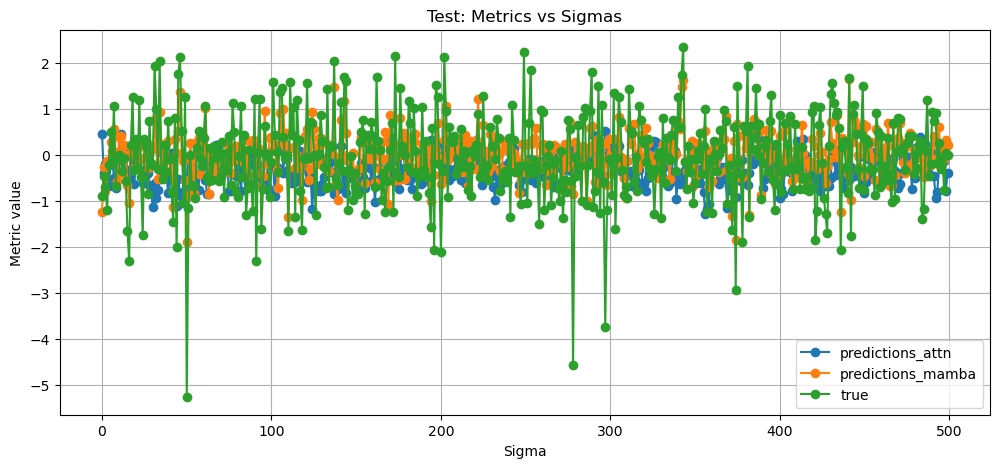

In [7]:
import matplotlib.pyplot as plt

xs = np.arange(preds[:, 0][:500].shape[0])


plt.figure(figsize=(12, 5))
plt.plot(xs, preds[:, 0][:500], marker="o", label="predictions_attn")
plt.plot(xs, preds2[:, 0][:500], marker="o", label="predictions_mamba")
plt.plot(xs, labels[:, 0][:500], marker="o", label="true")
plt.xlabel("Sigma")
plt.ylabel("Metric value")
plt.title("Test: Metrics vs Sigmas")
plt.grid(True)
plt.legend()
plt.show()

# plt.figure(figsize=(12, 5))
# plt.plot(xs, preds2[:, 0][:500], marker="o", label="predictions")
# plt.plot(xs, labels2[:, 0][:500], marker="o", label="true")
# plt.xlabel("Sigma")
# plt.ylabel("Metric value")
# plt.title("Test: Metrics vs Sigmas")
# plt.grid(True)
# plt.legend()
# plt.show()


ATTN preds shape: (17649, 64)
MAMBA preds shape: (17649, 64)
labels shape: (17649, 64)
n_series: 477
n_windows: 37
pred_len: 64
Eval slice start index: 149
First forecast date: 2021-08-11 00:00:00
Last forecast date: 2021-10-01 00:00:00
Expected true AAPL segment shape: (37,)
series_major: mean abs alignment error = 0.3734674974
window_major: mean abs alignment error = 0.3724624407

Chosen layout: window_major (alignment MAE=0.3724624407)
AAPL attn shape: (37, 64)
AAPL true shape: (37, 64)
AAPL mamba shape: (37, 64)
True-vs-CSV MAE: 0.4214661476347087


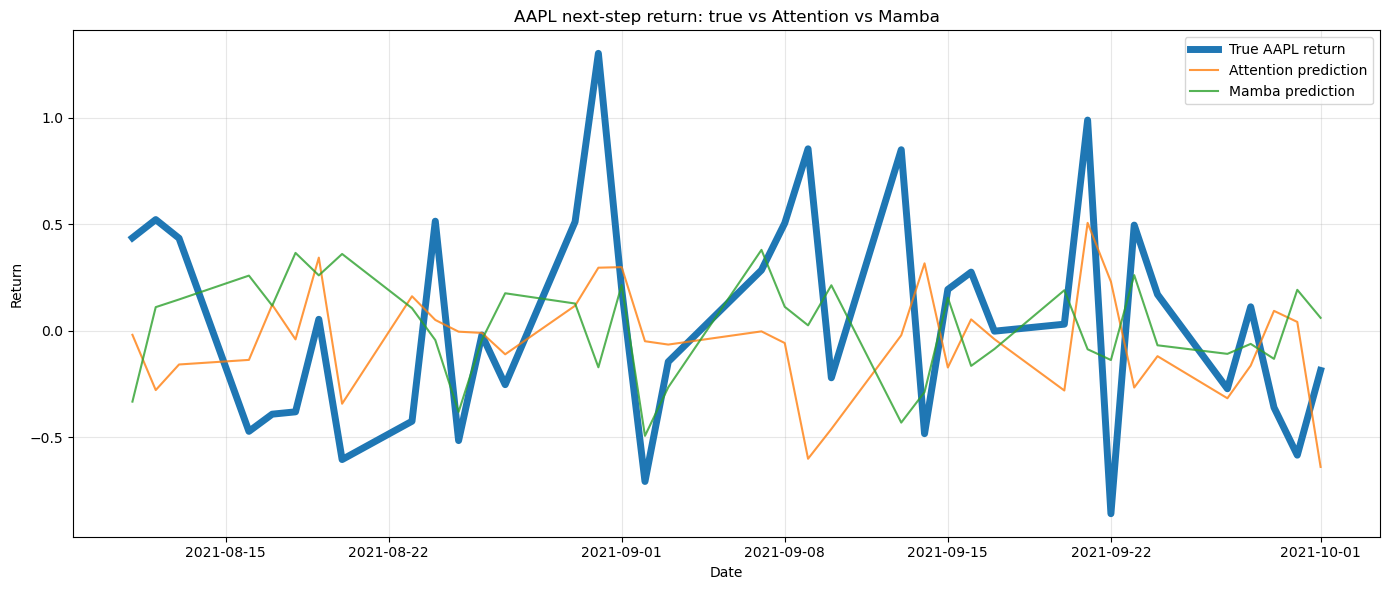

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "dataset_finance/eval/covid_2020_2021.csv"
attn_path = "results/eval_preds_attn_small_covid.npz"
mamba_path = "results/eval_preds_mamba_small_covid.npz"

prediction_length = 64
context_length = 256   # because run_eval uses p*4 for p=64 unless overridden
target = "AAPL"

# ---------- load csv ----------
df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

feature_cols = [c for c in df.columns if c != "date"]
n_series = len(feature_cols)
target_idx = feature_cols.index(target)

# ---------- load npz ----------
attn = np.load(attn_path)
mamba = np.load(mamba_path)

attn_preds = attn["predictions"]
attn_labels = attn["labels"]
mamba_preds = mamba["predictions"]

print("ATTN preds shape:", attn_preds.shape)
print("MAMBA preds shape:", mamba_preds.shape)
print("labels shape:", attn_labels.shape)
print("n_series:", n_series)

assert attn_preds.shape == attn_labels.shape == mamba_preds.shape
assert attn_preds.shape[0] % n_series == 0

n_windows = attn_preds.shape[0] // n_series
pred_len = attn_preds.shape[1]

print("n_windows:", n_windows)
print("pred_len:", pred_len)

# ---------- compute exact evaluation date block ----------
used_rows = context_length + n_windows + prediction_length - 1
eval_slice_start = len(df) - used_rows
first_label_idx = eval_slice_start + context_length
last_label_idx = first_label_idx + n_windows

dates_eval = df["date"].iloc[first_label_idx:last_label_idx].reset_index(drop=True)
true_aapl_from_csv = df[target].iloc[first_label_idx:last_label_idx].to_numpy()

print("Eval slice start index:", eval_slice_start)
print("First forecast date:", dates_eval.iloc[0])
print("Last forecast date:", dates_eval.iloc[-1])
print("Expected true AAPL segment shape:", true_aapl_from_csv.shape)

# ---------- try both possible reshapes ----------
def reshape_series_major(x):
    # assumes rows grouped by series first, then windows
    return x.reshape(n_series, n_windows, pred_len)

def reshape_window_major(x):
    # assumes rows grouped by windows first, then series
    return x.reshape(n_windows, n_series, pred_len).transpose(1, 0, 2)

candidates = {
    "series_major": (
        reshape_series_major(attn_preds),
        reshape_series_major(attn_labels),
        reshape_series_major(mamba_preds),
    ),
    "window_major": (
        reshape_window_major(attn_preds),
        reshape_window_major(attn_labels),
        reshape_window_major(mamba_preds),
    ),
}

best_name = None
best_err = None
best_pack = None

for name, (attn_3d, labels_3d, mamba_3d) in candidates.items():
    # compare t+1 labels for AAPL with actual AAPL values on eval dates
    candidate_true = labels_3d[target_idx, :, 0]
    err = np.mean(np.abs(candidate_true - true_aapl_from_csv))
    print(f"{name}: mean abs alignment error = {err:.10f}")

    if best_err is None or err < best_err:
        best_err = err
        best_name = name
        best_pack = (attn_3d, labels_3d, mamba_3d)

print(f"\nChosen layout: {best_name} (alignment MAE={best_err:.10f})")

attn_3d, labels_3d, mamba_3d = best_pack

# ---------- extract AAPL ----------
aapl_attn = attn_3d[target_idx]    # [n_windows, pred_len]
aapl_true = labels_3d[target_idx]  # [n_windows, pred_len]
aapl_mamba = mamba_3d[target_idx]  # [n_windows, pred_len]

print("AAPL attn shape:", aapl_attn.shape)
print("AAPL true shape:", aapl_true.shape)
print("AAPL mamba shape:", aapl_mamba.shape)

# First-step forecast (t+1)
true_t1 = aapl_true[:, 1]
attn_t1 = aapl_attn[:, 1]
mamba_t1 = aapl_mamba[:, 1]

# sanity check
print("True-vs-CSV MAE:", np.mean(np.abs(true_t1 - true_aapl_from_csv)))

# ---------- save comparison table ----------
comparison_df = pd.DataFrame({
    "date": dates_eval,
    "AAPL_true_t1": true_t1,
    "AAPL_attn_t1": attn_t1,
    "AAPL_mamba_t1": mamba_t1,
    "attn_error": attn_t1 - true_t1,
    "mamba_error": mamba_t1 - true_t1,
})

# comparison_df.to_csv("AAPL_t1_predictions_comparison.csv", index=False)

# ---------- plot ----------
plt.figure(figsize=(14, 6))
plt.plot(dates_eval, true_t1, label="True AAPL return", linewidth=5)
plt.plot(dates_eval, attn_t1, label="Attention prediction", alpha=0.8)
plt.plot(dates_eval, mamba_t1, label="Mamba prediction", alpha=0.8)
plt.title("AAPL next-step return: true vs Attention vs Mamba")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig("AAPL_true_attn_mamba_t1.png", dpi=150)
plt.show()


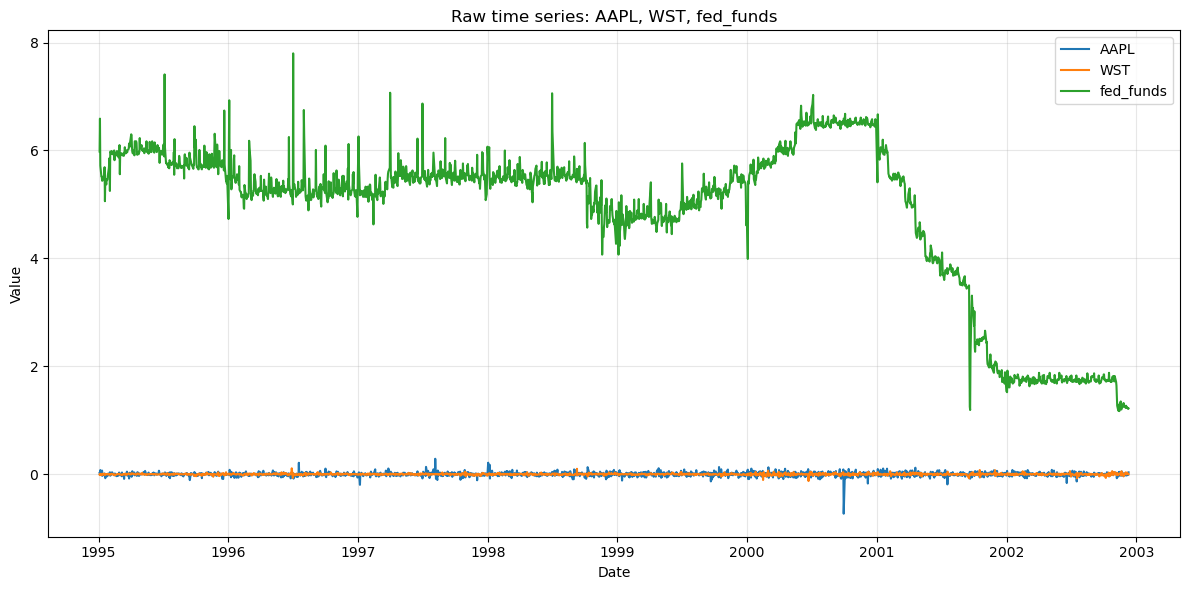

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = "dataset_finance/eval/full_panel_preview.csv"

df = pd.read_csv(csv_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

cols = ["AAPL", "WST", "fed_funds"]

# --- 1) Raw series plot ---
plt.figure(figsize=(12, 6))
for col in cols:
    plt.plot(df["date"], df[col], label=col)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Raw time series: AAPL, WST, fed_funds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# # --- 2) Stock cumulative return indices + fed_funds level ---
# cum_df = df[["date"]].copy()

# for col in ["AAPL", "WST"]:
#     # Build a cumulative index starting at 100
#     cum_df[col + "_cum"] = 100 * (1 + df[col].fillna(0)).cumprod()

# cum_df["fed_funds"] = df["fed_funds"]

# fig, ax1 = plt.subplots(figsize=(12, 6))

# ax1.plot(cum_df["date"], cum_df["AAPL_cum"], label="AAPL cumulative index")
# ax1.plot(cum_df["date"], cum_df["WST_cum"], label="WST cumulative index")
# ax1.set_xlabel("Date")
# ax1.set_ylabel("Cumulative return index")
# ax1.grid(True, alpha=0.3)

# ax2 = ax1.twinx()
# ax2.plot(cum_df["date"], cum_df["fed_funds"], linestyle="--", label="fed_funds")
# ax2.set_ylabel("Fed funds rate")

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# plt.title("AAPL and WST cumulative indices with fed_funds")
# plt.tight_layout()
# plt.show()
# # plt.savefig("cum_returns_with_fedfunds.png", dpi=150)
# plt.close()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_preds_vs_true(npz_path, ticker=None, start_date=None, end_date=None, save_path=None):
    data = np.load(npz_path, allow_pickle=True)

    preds = data["predictions"]
    labels = data["labels"]

    if "dates" not in data:
        raise ValueError("No 'dates' found in npz. Save dates during evaluation first.")
    dates = pd.to_datetime(data["dates"])

    if preds.ndim > 1:
        preds = preds.squeeze()
    if labels.ndim > 1:
        labels = labels.squeeze()

    df = pd.DataFrame({
        "date": dates,
        "pred": preds,
        "true": labels,
    })

    if "tickers" in data:
        tickers = data["tickers"]
        df["ticker"] = tickers
        if ticker is not None:
            df = df[df["ticker"] == ticker]

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]
    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    df = df.sort_values("date").reset_index(drop=True)

    if len(df) == 0:
        raise ValueError("No rows left after filtering.")

    plt.figure(figsize=(14, 6))
    plt.plot(df["date"], df["true"], label="True returns", linewidth=1.5)
    plt.plot(df["date"], df["pred"], label="Predicted returns", linewidth=1.2, alpha=0.9)

    title = "Predicted vs True Returns"
    if ticker is not None:
        title += f" | {ticker}"

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print(f"Saved plot to {save_path}")
    else:
        plt.show()


plot_preds_vs_true(
    npz_path="results/gfc_preds.npz",
    ticker="AAPL",
    # save_path="plots/gfc_aapl_preds_vs_true.png",
)

In [1]:
import os, glob, json, pathlib

CKPT_DIR = "logs/time_moe_attn_small"  # <-- change this

paths = sorted(glob.glob(os.path.join(CKPT_DIR, "*")))
print("Checkpoint dir:", CKPT_DIR)
print("Files:")
for p in paths:
    print(" -", os.path.basename(p))


Checkpoint dir: logs/time_moe_attn_small
Files:
 - config.json
 - generation_config.json
 - model.safetensors
 - training_args.bin


In [3]:
import os, glob
from safetensors.torch import safe_open


p = "logs/time_moe_attn_small/model.safetensors"
with safe_open(p, framework="pt", device="cpu") as f:
    for k in f.keys():
        shape = f.get_tensor(k).shape
        n = 1
        for d in shape:
            n *= d
        total_params += n
        tensors += 1

print(f"Found {len(safetensor_paths)} safetensors file(s)")
print(f"Found {tensors} tensors")
print(f"Total parameters: {total_params:,}")


Found 1 safetensors file(s)
Found 657 tensors
Total parameters: 160,458,240


In [4]:
import os

total_bytes = os.path.getsize(p)

print(f"Total checkpoint weight size: {total_bytes/1024**2:.2f} MB ({total_bytes/1024**3:.3f} GB)")


Total checkpoint weight size: 432.46 MB (0.422 GB)


In [5]:
import json, os

config_path = os.path.join(CKPT_DIR, "config.json")
if os.path.exists(config_path):
    config = json.load(open(config_path, "r"))
    print("config.json keys:", list(config.keys())[:30], "..." if len(config.keys()) > 30 else "")
    # Print the most interesting fields if present:
    interesting = [
        "model_type", "hidden_size", "num_hidden_layers", "num_attention_heads",
        "intermediate_size", "num_experts", "num_experts_per_tok",
        "max_position_embeddings", "input_size",
        "mamba_d_state", "mamba_d_conv", "mamba_expand", "temporal_mixer"
    ]
    for k in interesting:
        if k in config:
            print(f"{k}: {config[k]}")
else:
    print("No config.json found in", CKPT_DIR)


config.json keys: ['apply_aux_loss', 'architectures', 'attention_dropout', 'auto_map', 'dtype', 'hidden_act', 'hidden_size', 'horizon_lengths', 'initializer_range', 'input_size', 'intermediate_size', 'mamba_d_conv', 'mamba_d_state', 'mamba_expand', 'max_position_embeddings', 'model_type', 'num_attention_heads', 'num_experts', 'num_experts_per_tok', 'num_hidden_layers', 'num_key_value_heads', 'rms_norm_eps', 'rope_theta', 'router_aux_loss_factor', 'temporal_mixer', 'tie_word_embeddings', 'transformers_version', 'use_cache', 'use_dense'] 
model_type: time_moe
hidden_size: 384
num_hidden_layers: 12
num_attention_heads: 12
intermediate_size: 1536
num_experts: 8
num_experts_per_tok: 2
max_position_embeddings: 4096
input_size: 1
mamba_d_state: 16
mamba_d_conv: 4
mamba_expand: 2
temporal_mixer: attn


In [8]:
summary = {}

# params
summary["total_params"] = total_params
summary["weights_size_gb"] = total_bytes/1024**3

# config bits if available
if os.path.exists(config_path):
    for k in ["hidden_size", "num_hidden_layers", "num_attention_heads", "intermediate_size",
              "num_experts", "num_experts_per_tok", "temporal_mixer"]:
        if k in config:
            summary[k] = config[k]


summary


{'total_params': 160458240,
 'weights_size_gb': 0.4223216474056244,
 'hidden_size': 384,
 'num_hidden_layers': 12,
 'num_attention_heads': 12,
 'intermediate_size': 1536,
 'num_experts': 8,
 'num_experts_per_tok': 2,
 'temporal_mixer': 'attn'}

In [8]:
import torch
from torch.utils.data import DataLoader

from time_moe.datasets.general_covariate_dataset import GeneralCovariateDataset
from time_moe.datasets.time_moe_covariate_window_dataset import TimeMoECovariateWindowDataset
from time_moe.runner import CovariateDataCollator


DATA_PATH = "dataset_finance_fred/finetune/train.jsonl"   # change this
MAX_LENGTH = 1024
STRIDE = 1024
BATCH_SIZE = 2


dataset = GeneralCovariateDataset(DATA_PATH)
window_dataset = TimeMoECovariateWindowDataset(
    dataset,
    context_length=MAX_LENGTH,
    prediction_length=0,
    stride=STRIDE,
)

collator = CovariateDataCollator()
loader = DataLoader(
    window_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collator,
)

batch = next(iter(loader))

print("Batch keys:", batch.keys())
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"{k}: shape={tuple(v.shape)}, dtype={v.dtype}")
    else:
        print(f"{k}: type={type(v)}")

# optional: sanity checks
print("\nSanity checks:")
print("main_features[0, 0] =", batch["main_features"][0, 0])
if "macro_features" in batch:
    print("macro_features[0, 0] =", batch["macro_features"][0, 0])
print("labels[0, :5] =", batch["labels"][0, :5])
print("loss_masks[0, :5] =", batch["loss_masks"][0, :5])
print("attention_mask[0, :5] =", batch["attention_mask"][0, :5])

Batch keys: dict_keys(['main_features', 'macro_features', 'labels', 'loss_masks', 'attention_mask'])
main_features: shape=(2, 1024, 2), dtype=torch.float32
macro_features: shape=(2, 1024, 7), dtype=torch.float32
labels: shape=(2, 1024), dtype=torch.float32
loss_masks: shape=(2, 1024), dtype=torch.int64
attention_mask: shape=(2, 1024), dtype=torch.int64

Sanity checks:
main_features[0, 0] = tensor([-0.0860, -0.0009])
macro_features[0, 0] = tensor([5.4900e+00, 6.0600e+00, 5.9000e+00, 1.6000e-01, 1.6840e+02, 4.1000e+00,
        9.0962e+01])
labels[0, :5] = tensor([ 0.0860, -0.0953,  0.0262,  0.0030,  0.0225])
loss_masks[0, :5] = tensor([1, 1, 1, 1, 1])
attention_mask[0, :5] = tensor([1, 1, 1, 1, 1])


In [2]:
import json
import math
import argparse
from pathlib import Path

import numpy as np


def read_jsonl(path):
    items = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            items.append(json.loads(line))
    return items


def huber_loss(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    abs_err = np.abs(err)
    quad = np.minimum(abs_err, delta)
    lin = abs_err - quad
    return 0.5 * quad**2 + delta * lin


def compute_metrics(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    mse = np.mean(err ** 2)
    rmse = math.sqrt(mse)
    mae = np.mean(np.abs(err))
    huber = np.mean(huber_loss(y_true, y_pred, delta=delta))
    return {
        "n": int(len(y_true)),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "huber": float(huber),
    }


def collect_targets_and_prev(items):
    """
    Для baseline'ов:
      1) zero predictor
      2) previous return predictor

    Если sequence = [r_1, r_2, ..., r_T],
    то модельный one-step target обычно:
      y_t = r_{t+1}
    а previous predictor:
      pred_t = r_t

    Значит:
      y_true = seq[1:]
      y_prev = seq[:-1]
    """
    ys = []
    prevs = []

    for item in items:
        seq = np.asarray(item["sequence"], dtype=np.float64)
        if len(seq) < 2:
            continue

        ys.append(seq[1:])
        prevs.append(seq[:-1])

    if not ys:
        raise ValueError("No usable sequences with length >= 2 found.")

    y_true = np.concatenate(ys, axis=0)
    y_prev = np.concatenate(prevs, axis=0)
    return y_true, y_prev


def collect_targets_and_market(items, market_col_idx=1):
    """
    Для linear baseline:
      y_{t+1} ~ alpha * market_t + beta

    Предполагается, что main_features[t] соответствует информации на момент t,
    а target = sequence[t+1].

    Тогда берем:
      X = main_features[:-1, market_col_idx]
      y = sequence[1:]
    """
    xs = []
    ys = []

    for item in items:
        if "main_features" not in item:
            continue

        seq = np.asarray(item["sequence"], dtype=np.float64)
        main = np.asarray(item["main_features"], dtype=np.float64)

        if len(seq) < 2:
            continue
        if len(main) != len(seq):
            raise ValueError(
                f"Length mismatch: len(sequence)={len(seq)} vs len(main_features)={len(main)}"
            )
        if main.ndim != 2:
            raise ValueError(f"main_features must be 2D, got shape={main.shape}")
        if main.shape[1] <= market_col_idx:
            raise ValueError(
                f"main_features has shape {main.shape}, but market_col_idx={market_col_idx}"
            )

        x = main[:-1, market_col_idx]
        y = seq[1:]

        xs.append(x)
        ys.append(y)

    if not xs:
        raise ValueError(
            "No usable 'main_features' found. "
            "This baseline needs the new covariate-aware jsonl format."
        )

    X = np.concatenate(xs, axis=0)
    y = np.concatenate(ys, axis=0)
    return X, y


def fit_linear_baseline(X, y):
    """
    Оценивает:
      y = alpha * X + beta

    обычным least squares.
    """
    A = np.column_stack([X, np.ones_like(X)])
    coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)
    alpha, beta = coeffs
    y_pred = alpha * X + beta
    return float(alpha), float(beta), y_pred


    
path = 'dataset_finance_fred/eval_jsonl/gfc_2008_2010.jsonl'
items = read_jsonl(path)

print(f"Loaded {len(items)} sequences from: {path}")

# 1) zero baseline
y_true, y_prev = collect_targets_and_prev(items)
y_zero = np.zeros_like(y_true)

zero_metrics = compute_metrics(y_true, y_zero, delta=2.0)
prev_metrics = compute_metrics(y_true, y_prev, delta=2.0)

print("\n=== Baseline: predict 0 ===")
for k, v in zero_metrics.items():
    print(f"{k}: {v}")

print("\n=== Baseline: predict previous return ===")
for k, v in prev_metrics.items():
    print(f"{k}: {v}")

# 2) linear market baseline, if main_features exist
has_main = any("main_features" in x for x in items)
if has_main:
    X_mkt, y_mkt = collect_targets_and_market(items, market_col_idx=1)
    alpha, beta, y_lin = fit_linear_baseline(X_mkt, y_mkt)
    lin_metrics = compute_metrics(y_mkt, y_lin, delta=2.0)

    print("\n=== Baseline: linear market predictor ===")
    print(f"formula: pred = {alpha:.8f} * market_return + {beta:.8f}")
    for k, v in lin_metrics.items():
        print(f"{k}: {v}")
else:
    print("\nNo main_features found, so linear market baseline was skipped.")


Loaded 430 sequences from: dataset_finance_fred/eval_jsonl/gfc_2008_2010.jsonl

=== Baseline: predict 0 ===
n: 318728
mse: 0.0010883708839546846
rmse: 0.03299046656163997
mae: 0.020741426923301432
huber: 0.0005441854419773423

=== Baseline: predict previous return ===
n: 318728
mse: 0.002284225431409736
rmse: 0.0477935710259208
mae: 0.030482959869496076
huber: 0.001142112715704868

=== Baseline: linear market predictor ===
formula: pred = -0.09857459 * market_return + -0.00003639
n: 318728
mse: 0.0010848736259087167
rmse: 0.032937419842919036
mae: 0.0207144445395485
huber: 0.0005424368129543583


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_preds_vs_true(npz_path, ticker=None, start_date=None, end_date=None, save_path=None):
    data = np.load(npz_path, allow_pickle=True)

    preds = data["predictions"]
    labels = data["labels"]

    if "dates" not in data:
        raise ValueError("No 'dates' found in npz. Save dates during evaluation first.")
    dates = pd.to_datetime(data["dates"])

    if preds.ndim > 1:
        preds = preds.squeeze()
    if labels.ndim > 1:
        labels = labels.squeeze()

    df = pd.DataFrame({
        "date": dates,
        "pred": preds,
        "true": labels,
    })

    if "tickers" in data:
        tickers = data["tickers"]
        df["ticker"] = tickers
        if ticker is not None:
            df = df[df["ticker"] == ticker]

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]
    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    df = df.sort_values("date").reset_index(drop=True)

    if len(df) == 0:
        raise ValueError("No rows left after filtering.")

    plt.figure(figsize=(14, 6))
    plt.plot(df["date"], df["true"], label="True returns", linewidth=1.5)
    plt.plot(df["date"], df["pred"], label="Predicted returns", linewidth=1.2, alpha=0.9)

    title = "Predicted vs True Returns"
    if ticker is not None:
        title += f" | {ticker}"

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # if save_path is not None:
    #     plt.savefig(save_path, dpi=150)
    #     print(f"Saved plot to {save_path}")
    # else:
    #     plt.show()


# examples:
plot_preds_vs_true(
    npz_path="results/mamba/gfc_p64.npz",
    ticker="AAPL",   # or "AAPL"
    # save_path="plots/gfc_preds_vs_true.png",
)

ValueError: Per-column arrays must each be 1-dimensional

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

def huber_loss(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    abs_err = np.abs(err)
    quad = np.minimum(abs_err, delta)
    lin = abs_err - quad
    return 0.5 * quad**2 + delta * lin


def compute_metrics(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    mse = np.mean(err ** 2)
    rmse = math.sqrt(mse)
    mae = np.mean(np.abs(err))
    huber = np.mean(huber_loss(y_true, y_pred, delta=delta))
    sign_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
    return {
        "n": int(len(y_true)),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "huber": float(huber),
        "sign_accuracy": float(sign_acc),
    }

data = np.load('results/mamba/cov_p64.npz', allow_pickle=True)

preds = data["predictions"]
labels = data["labels"]
compute_metrics(labels, preds)

{'n': 90172,
 'mse': 0.04175176570148203,
 'rmse': 0.2043324881204211,
 'mae': 0.15891425338233794,
 'huber': 0.020857558453310755,
 'sign_accuracy': 0.5013690849154948}

In [7]:
data = np.load('results/mamba_fred/cov_p64.npz', allow_pickle=True)

preds = data["predictions"]
labels = data["labels"]
compute_metrics(labels, preds)

{'n': 90660,
 'mse': 0.0003062016621697694,
 'rmse': 0.01749861886463527,
 'mae': 0.012357371859252453,
 'huber': 0.0001531008310848847,
 'sign_accuracy': 0.49881011471431724}

In [10]:
import numpy as np

data = np.load("results/mamba_fred/cov_p64.npz", allow_pickle=True)

for k in data.files:
    arr = data[k]
    print(k, np.array(arr).shape, np.array(arr).dtype)

predictions (90660, 64) float32
labels (90660, 64) float32
dates (5802240,) object
tickers (90660,) object


In [2]:
data = np.load("results/mamba/cov_p64.npz", allow_pickle=True)

for k in data.files:
    arr = data[k]
    print(k, np.array(arr).shape, np.array(arr).dtype)

predictions (90172, 64) float64
labels (90172, 64) float64
dates (0,) object
tickers (0,) object


In [ ]:
import argparse
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from arch import arch_model


def huber_loss(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    abs_err = np.abs(err)
    quad = np.minimum(abs_err, delta)
    lin = abs_err - quad
    return 0.5 * quad**2 + delta * lin


def compute_metrics(y_true, y_pred, delta=2.0):
    err = y_true - y_pred
    mse = np.mean(err ** 2)
    rmse = math.sqrt(mse)
    mae = np.mean(np.abs(err))
    huber = np.mean(huber_loss(y_true, y_pred, delta=delta))
    sign_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
    return {
        "n": int(len(y_true)),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "huber": float(huber),
        "sign_accuracy": float(sign_acc),
    }


def one_step_garch_forecast(series, warmup=256, mean_type="AR", p=1, q=1, dist="normal"):
    """
    Expanding-window one-step-ahead forecasts for one return series.

    series: pd.Series indexed by date
    returns:
      pred_df with columns [date, y_true, y_pred]
    """
    s = pd.Series(series).dropna().astype(float)
    if len(s) <= warmup + 1:
        return pd.DataFrame(columns=["date", "y_true", "y_pred"])

    dates = []
    y_true = []
    y_pred = []

    values = s.values
    idx = s.index

    # arch often behaves better if returns are scaled from ~0.01 to ~1
    scale = 100.0
    scaled_values = values * scale

    for t in range(warmup, len(s) - 1):
        train = scaled_values[:t]

        try:
            if mean_type.upper() == "AR":
                am = arch_model(
                    train,
                    mean="AR",
                    lags=1,
                    vol="GARCH",
                    p=p,
                    q=q,
                    dist=dist,
                    rescale=False,
                )
            else:
                am = arch_model(
                    train,
                    mean="Constant",
                    vol="GARCH",
                    p=p,
                    q=q,
                    dist=dist,
                    rescale=False,
                )

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = am.fit(disp="off", show_warning=False)

            fcast = res.forecast(horizon=1, reindex=False)

            # mean forecast for next step
            pred_scaled = float(fcast.mean.values[-1, 0])
            pred = pred_scaled / scale

            dates.append(idx[t + 1])
            y_true.append(values[t + 1])
            y_pred.append(pred)

        except Exception:
            # skip unstable fits
            continue

    return pd.DataFrame({
        "date": dates,
        "y_true": y_true,
        "y_pred": y_pred,
    })


def run_eval(csv_path, warmup=256, mean_type="AR", p=1, q=1, dist="normal",
             save_preds_path=None, tickers_subset=None):
    df = pd.read_csv(csv_path)

    # try to infer date column
    date_col = None
    for c in df.columns:
        if c.lower() in {"date", "datetime", "timestamp"}:
            date_col = c
            break

    if date_col is None:
        raise ValueError("Could not find a date column in CSV.")

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).set_index(date_col)

    # columns that are clearly not firm returns
    exclude = {
        "market_ret_1d",
        "fed_funds", "rate_10y", "rate_2y", "yc_slope_10y2y",
        "cpi", "unemp", "indpro"
    }

    candidate_cols = [c for c in df.columns if c not in exclude]

    if tickers_subset is not None:
        tickers_subset = set(tickers_subset)
        candidate_cols = [c for c in candidate_cols if c in tickers_subset]

    all_pred_rows = []

    for ticker in candidate_cols:
        s = df[ticker].dropna()
        if len(s) <= warmup + 1:
            continue

        pred_df = one_step_garch_forecast(
            s,
            warmup=warmup,
            mean_type=mean_type,
            p=p,
            q=q,
            dist=dist,
        )
        if len(pred_df) == 0:
            continue
        pred_df["ticker"] = ticker
        all_pred_rows.append(pred_df)

    if not all_pred_rows:
        raise ValueError("No usable forecasts were produced.")

    pred_all = pd.concat(all_pred_rows, axis=0, ignore_index=True)

    metrics = compute_metrics(
        pred_all["y_true"].values,
        pred_all["y_pred"].values,
        delta=2.0,
    )

    print("\n=== GARCH baseline results ===")
    print(metrics)

    if save_preds_path is not None:
        out = Path(save_preds_path)
        out.parent.mkdir(parents=True, exist_ok=True)
        pred_all.to_csv(out, index=False)
        print(f"Saved predictions to: {out}")

    return pred_all, metrics



csv_path = 'dataset_finance_fred/eval/inflation_2022_2023.csv'
warmup = 256
mean_type = 'AR'  # Constant
p = 1
q = 1
dist = 'normal'
save_preds_path = 'results/garch_preds_inf.csv'
tickers_subset = None

run_eval(csv_path, warmup, mean_type, p, q, dist, save_preds_path, tickers_subset)




=== GARCH baseline results ===
{'n': 120527, 'mse': 0.00035981998529295426, 'rmse': 0.01896892156378307, 'mae': 0.012732721694780349, 'huber': 0.00017990999264647713, 'sign_accuracy': 0.49719150065960327}
Saved predictions to: results/garch_preds_inf.csv


(             date    y_true    y_pred ticker
 0      2023-01-11  0.018763 -0.000212      A
 1      2023-01-12 -0.010678 -0.001074      A
 2      2023-01-13  0.002744 -0.000188      A
 3      2023-01-17 -0.009734  0.000146      A
 4      2023-01-18 -0.008595 -0.000029      A
 ...           ...       ...       ...    ...
 120522 2023-12-22  0.001643 -0.001799    ZTS
 120523 2023-12-26  0.002663 -0.000146    ZTS
 120524 2023-12-27  0.007136 -0.000004    ZTS
 120525 2023-12-28  0.001320  0.000097    ZTS
 120526 2023-12-29  0.001065  0.000529    ZTS
 
 [120527 rows x 4 columns],
 {'n': 120527,
  'mse': 0.00035981998529295426,
  'rmse': 0.01896892156378307,
  'mae': 0.012732721694780349,
  'huber': 0.00017990999264647713,
  'sign_accuracy': 0.49719150065960327})

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_predictions_long(npz_path):
    data = np.load(npz_path, allow_pickle=True)

    preds = data["predictions"]
    labels = data["labels"]

    if preds.ndim == 1:
        preds = preds.reshape(-1, 1)
    if labels.ndim == 1:
        labels = labels.reshape(-1, 1)

    if preds.shape != labels.shape:
        raise ValueError(f"predictions shape {preds.shape} != labels shape {labels.shape}")

    n_samples, horizon = preds.shape

    if "dates" not in data:
        raise ValueError("No 'dates' found in npz. Save dates during evaluation first.")

    raw_dates = np.array(data["dates"], dtype=object)

    # possible date formats:
    # 1) flat length N*H
    # 2) shape [N, H]
    # 3) shape [N] only when H=1
    if raw_dates.ndim == 2:
        if raw_dates.shape != (n_samples, horizon):
            raise ValueError(
                f"dates shape {raw_dates.shape} does not match predictions shape {(n_samples, horizon)}"
            )
        dates = raw_dates
    else:
        if raw_dates.size == n_samples * horizon:
            dates = raw_dates.reshape(n_samples, horizon)
        elif raw_dates.size == n_samples and horizon == 1:
            dates = raw_dates.reshape(n_samples, 1)
        else:
            raise ValueError(
                f"Cannot align dates of size {raw_dates.size} with predictions shape {(n_samples, horizon)}"
            )

    dates = np.asarray(pd.to_datetime(np.asarray(dates).ravel())).reshape(n_samples, horizon)

    # tickers can be:
    # 1) length N
    # 2) length N*H
    # 3) absent
    tickers = None
    if "tickers" in data:
        raw_tickers = np.array(data["tickers"], dtype=object)

        if raw_tickers.ndim == 2:
            if raw_tickers.shape != (n_samples, horizon):
                raise ValueError(
                    f"tickers shape {raw_tickers.shape} does not match predictions shape {(n_samples, horizon)}"
                )
            tickers = raw_tickers
        else:
            if raw_tickers.size == n_samples:
                tickers = np.repeat(raw_tickers.reshape(-1, 1), horizon, axis=1)
            elif raw_tickers.size == n_samples * horizon:
                tickers = raw_tickers.reshape(n_samples, horizon)
            else:
                raise ValueError(
                    f"Cannot align tickers of size {raw_tickers.size} with predictions shape {(n_samples, horizon)}"
                )

    rows = []
    for i in range(n_samples):
        for h in range(horizon):
            row = {
                "date": dates[i, h],
                "pred": float(preds[i, h]),
                "true": float(labels[i, h]),
                "horizon_step": h + 1,
                "sample_id": i,
            }
            if tickers is not None:
                row["ticker"] = tickers[i, h]
            rows.append(row)

    df = pd.DataFrame(rows)
    return df


def plot_preds_vs_true(
    npz_path,
    ticker=None,
    horizon_step=None,
    start_date=None,
    end_date=None,
    aggregate_by_date=True,
    save_path=None,
):
    df = load_predictions_long(npz_path)

    if ticker is not None:
        if "ticker" not in df.columns:
            raise ValueError("Ticker filter requested, but no tickers stored in npz.")
        df = df[df["ticker"] == ticker]

    if horizon_step is not None:
        df = df[df["horizon_step"] == horizon_step]

    if start_date is not None:
        df = df[df["date"] >= pd.to_datetime(start_date)]
    if end_date is not None:
        df = df[df["date"] <= pd.to_datetime(end_date)]

    if len(df) == 0:
        raise ValueError("No rows left after filtering.")

    df = df.sort_values("date").reset_index(drop=True)

    # Because windows overlap, the same date can appear many times.
    # Usually for plotting it is cleaner to average them by date.
    if aggregate_by_date:
        group_cols = ["date"]
        if ticker is not None and "ticker" in df.columns:
            group_cols.append("ticker")
        if horizon_step is not None:
            group_cols.append("horizon_step")

        df_plot = (
            df.groupby(group_cols, as_index=False)[["pred", "true"]]
            .mean()
            .sort_values("date")
        )
    else:
        df_plot = df

    plt.figure(figsize=(14, 6))
    plt.plot(df_plot["date"], df_plot["true"], label="True returns", linewidth=1.5)
    plt.plot(df_plot["date"], df_plot["pred"], label="Predicted returns", linewidth=1.2, alpha=0.9)

    title = "Predicted vs True Returns"
    if ticker is not None:
        title += f" | {ticker}"
    if horizon_step is not None:
        title += f" | horizon step {horizon_step}"

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Returns")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print(f"Saved plot to {save_path}")
    else:
        plt.show()

plot_preds_vs_true(
    npz_path="results/mamba/gfc_p64.npz",
    ticker="AAPL",
    horizon_step=1,
    aggregate_by_date=True,
)

ValueError: Cannot align dates of size 0 with predictions shape (182748, 64)

In [16]:
data = np.load("results/gfc_mamba_fred_p64.npz", allow_pickle=True)
preds = data["predictions"]
labels = data["labels"]
preds.reshape(-1, 1)

array([[ 0.00076054],
       [ 0.0009648 ],
       [-0.00056049],
       ...,
       [ 0.00086676],
       [ 0.00072076],
       [-0.00087138]], dtype=float32)